**Opening**
In last notebook(mould-risk-analysis-v2), I promised that I would make another notebook-v3 with the newly installed dMEV styled fan. 
This was meant to pin down the effect of the newly installed dMEV styled fan: how fast it helps the room get away from the risk zone(when dewpoint spread is <=3 ).
There are 3 groups to compared
1. the last 2weeks before 11/05/2026
2. the first 2weeks after 11/05/2026
3. after after 2weeks after 05/06/2026

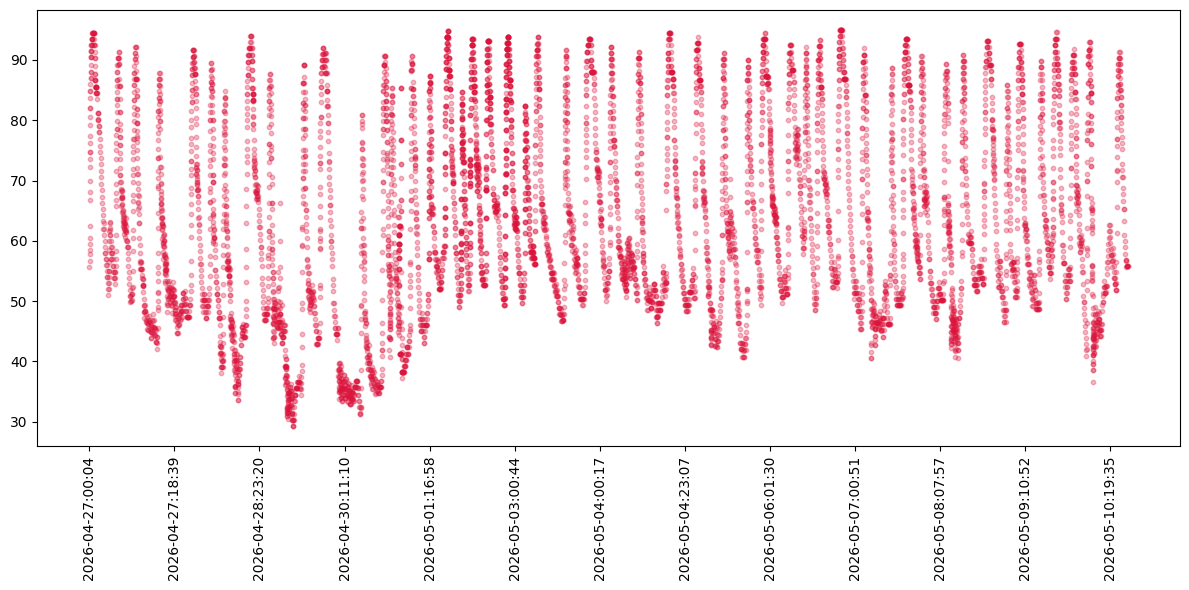

In [606]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from matplotlib.colors import Normalize
import matplotlib.cm as cm

# difficult to decide noise level, and decide on deflecting noise process
NOISE_THRESHOLD = 0.5

pd.set_option('display.max_rows', None)
df = pd.read_csv('./data/humid_temp_readings_v3.csv')
df = df[df['label'] == 'bathroom/bathtub_shelf_humid_temp_sensor'].copy()
df['ts'] = pd.to_datetime(df['received_at'], utc=True).dt.tz_convert('Europe/London')


df['date'] = df['ts'].dt.strftime('%Y-%m-%d:%H:%M')
# dbs usually save data in heap file randomly so, default, innodb mySQL uses, uses covering indexing(indexing file has the data -> indexing table is actually just tables, they all have indexed col)

w1_start = pd.to_datetime('2026-04-27').tz_localize('Europe/London')
w1_end = pd.to_datetime('2026-05-11').tz_localize('Europe/London')

w2_start = pd.to_datetime('2026-05-12').tz_localize('Europe/London')
w2_end = pd.to_datetime('2026-05-26').tz_localize('Europe/London')

w3_start = pd.to_datetime('2026-06-09').tz_localize('Europe/London')
w3_end = pd.to_datetime('2026-06-22').tz_localize('Europe/London')




time_mask = (w1_start <= df['ts']) & (w1_end >= df['ts']) 
time_mask2 = (w2_start <= df['ts'] ) & (w2_end >= df['ts'])
time_mask3 = (w3_start <= df['ts'] ) & (w3_end >= df['ts'])

df1 = df[time_mask].copy()
df1 = df[time_mask].sort_values('ts').reset_index(drop=True) 

df2 = df[time_mask2].copy()
df2 = df[time_mask2].sort_values('ts').reset_index(drop=True) 

df3 = df[time_mask3].copy()
df3 = df[time_mask3].sort_values('ts').reset_index(drop=True) 

L, B = 17.625, 243.04
alpha = ((L * df1['temperature']) / (B + df1['temperature'])) + np.log(df1['humidity'] / 100.0)
alpha2 = ((L * df2['temperature']) / (B + df2['temperature'])) + np.log(df2['humidity'] / 100.0)
alpha3 = ((L * df3['temperature']) / (B + df3['temperature'])) + np.log(df3['humidity'] / 100.0)

df1['dewpoint'] = (B * alpha) / (L - alpha)
df2['dewpoint']= (B * alpha2) / (L - alpha2)
df3['dewpoint']= (B * alpha3) / (L - alpha3)

df1['spread']  = (df1['temperature'] - df1['dewpoint']).round(1)
df2['spread']  = (df2['temperature'] - df2['dewpoint']).round(1)
df3['spread']  = (df3['temperature'] - df3['dewpoint']).round(1)



_df1 = df1.drop(columns=['device_id','linkquality', 'comfort_humidity_min', 'comfort_temperature_max', 'comfort_humidity_max', 'comfort_temperature_min', 'humidity_calibration', 'temperature_calibration', 'temperature_units', 'idempotency_key', 'battery'])
_df2 = df2.drop(columns=['device_id','linkquality', 'comfort_humidity_min', 'comfort_temperature_max', 'comfort_humidity_max', 'comfort_temperature_min', 'humidity_calibration', 'temperature_calibration', 'temperature_units', 'idempotency_key', 'battery'])
_df3 = df3.drop(columns=['device_id','linkquality', 'comfort_humidity_min', 'comfort_temperature_max', 'comfort_humidity_max', 'comfort_temperature_min', 'humidity_calibration', 'temperature_calibration', 'temperature_units', 'idempotency_key', 'battery'])


fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(
    _df1['date'],
    _df1['humidity'],
    color='crimson',
    alpha=0.3,
    s=10
)
plt.xticks(rotation=90, ha='center')
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=15))
plt.tight_layout()




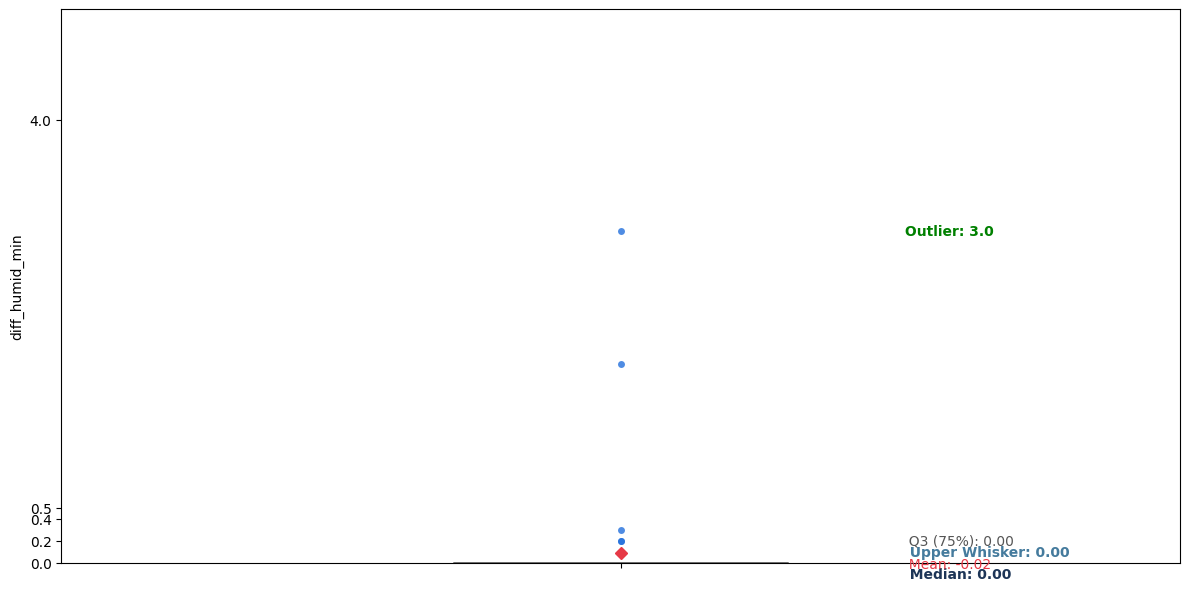

/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_17820/2223302260.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Bathtub Shelf Sensor"])


<Figure size 640x480 with 0 Axes>

In [ ]:
# 상자수염그림으로 outlier 찾아내기
def create_box_whisker_data(data):
    clean_time_mask = (data['ts'].dt.hour >= 3) & (data['ts'].dt.hour < 6)
    baseline_df = data[clean_time_mask].copy()
    baseline_df['diff_time_min'] = baseline_df['ts'].diff().dt.total_seconds()/60
    baseline_df = baseline_df.dropna(subset=['diff_time_min']).reset_index(drop = True)
    baseline_df['diff_humid'] = baseline_df['humidity'].diff()
    baseline_df = baseline_df.dropna(subset=['diff_humid']).reset_index(drop = True)
    
    baseline_df['diff_humid_min'] = (baseline_df['diff_humid'] / baseline_df['diff_time_min']).round(1)
    cl_df1 = baseline_df[baseline_df['diff_humid'] >= 0]
    data_points = baseline_df['diff_humid_min'].dropna()
    data_points = baseline_df['diff_humid_min'].dropna()
    q1 = np.percentile(data_points, 25)
    median = np.percentile(data_points, 50)
    q3 = np.percentile(data_points, 75)
    mean = np.mean(data_points)
    iqr = q3 - q1
    upper_whisker = q3 + (1.5 * iqr)
    desc_base = baseline_df['diff_humid']
    actual_upper_whisker = np.max(data_points[data_points <= upper_whisker])
    outliers_df = baseline_df[baseline_df['diff_humid_min'] > upper_whisker]
    outlier_val = baseline_df["diff_humid_min"].max()
    return {
        "q1": q1,
        "median": median,
        "q3": q3,
        "mean": mean,
        "upper_whisker": upper_whisker,
        "actual_upper_whisker": actual_upper_whisker,
        "outliers_df": outliers_df,
        "outlier_val": outlier_val,
        "summary": data_points.describe(),
        "desc_base": desc_base
    }

clean_time_mask = (_df1['ts'].dt.hour >= 3) & (_df1['ts'].dt.hour < 6)
baseline_df = _df1[clean_time_mask].copy()
baseline_df['diff_time_min'] = baseline_df['ts'].diff().dt.total_seconds()/60
baseline_df = baseline_df.dropna(subset=['diff_time_min']).reset_index(drop = True)
baseline_df['diff_humid'] = baseline_df['humidity'].diff()
baseline_df = baseline_df.dropna(subset=['diff_humid']).reset_index(drop = True)

baseline_df['diff_humid_min'] = (baseline_df['diff_humid'] / baseline_df['diff_time_min']).round(1)
cl_df1 = baseline_df[baseline_df['diff_humid'] >= 0]
data_points = baseline_df['diff_humid_min'].dropna()
data_points = baseline_df['diff_humid_min'].dropna()
q1 = np.percentile(data_points, 25)
median = np.percentile(data_points, 50)
q3 = np.percentile(data_points, 75)
mean = np.mean(data_points)
iqr = q3 - q1
upper_whisker = q3 + (1.5 * iqr)
desc_base = baseline_df['diff_humid']
actual_upper_whisker = np.max(data_points[data_points <= upper_whisker])
outliers_df = baseline_df[baseline_df['diff_humid_min'] > upper_whisker]
outlier_val = baseline_df["diff_humid_min"].max()
fig, ax = plt.subplots(figsize=(12,6))
box = sns.boxplot(
    data=cl_df1,
    y="diff_humid_min",
    ax=ax,
    color="#A8DADC",  
    width=0.3, 
    linewidth=2,  
    showmeans=True,  
    meanprops={
        "marker": "D",
        "markerfacecolor": "#E63946",
        "markeredgecolor": "#E63946",
        "markersize": 6,
    },  # 평균점 스타일
    flierprops={
        "marker": "o",
        "markerfacecolor": "#2370DC",
        "markeredgecolor": "none",
        "markersize": 5,
        "alpha": 0.8,
    }
)
text_x = 0.25  # 슬림해진 상자 옆 공간으로 바짝 붙임
ax.text(
    text_x,
    outlier_val,
    f" Outlier: {outlier_val}",
    color="green",
    fontweight="bold",
    va="center"
) 
ax.text(
    text_x,
    actual_upper_whisker + 0.10,
    f"  Upper Whisker: {actual_upper_whisker:.2f}",
    color="#457B9D",
    fontweight="bold",
    va="center",
)
ax.text(text_x, q3 + 0.20, f"  Q3 (75%): {q3:.2f}", color="#555555", va="center")
ax.text(
    text_x,
    median - 0.10,
    f"  Median: {median:.2f}",
    color="#1D3557",
    fontweight="bold",
    va="center",
)
ax.text(text_x, mean - 0, f"  Mean: {mean:.2f}", color="#E63946", va="center")
ax.set_ylim(0, 5.0)
ax.set_yticks([0.0, 0.2, 0.4, 0.5, 4.0])
plt.tight_layout()
plt.show()
ax.set_title(
    "Box plot whisker", fontsize=14, fontweight="bold", pad=15
)
ax.set_ylabel("Change per Minute (%/min)", fontsize=11)
ax.set_xticklabels(["Bathtub Shelf Sensor"])

# 불필요한 테두리 선 지우기 (오른쪽, 위)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [ ]:
# 찾아진 outlier를 통해서, event횟수 정의하기
shower_df = _df1.copy()

shower_df['diff_time'] = _df1['ts'].diff().dt.total_seconds().round(2)
shower_df['diff_time_min'] = shower_df['diff_time']/60
shower_df = shower_df.dropna(subset='diff_time_min').reset_index(drop=True)
shower_df['diff_humidity_min'] = (shower_df['humidity'].diff()/shower_df['diff_time_min']).round(2)
shower_df = shower_df[(shower_df['diff_humidity_min'] > 0) & (shower_df['diff_time_min'] != 0)]
shower_df['is_rising'] = shower_df['diff_humidity_min'] >= 3


rising_rows = shower_df[shower_df['is_rising']].copy()
rising_rows['time_gap'] = rising_rows['ts'].diff().dt.total_seconds() / 60
rising_rows['group'] = (rising_rows['time_gap'] > 10) | (rising_rows['time_gap'].isna())
rising_rows['event_id'] = rising_rows['group'].cumsum()

events = rising_rows.groupby('event_id').agg(
    start_time=('ts', 'min'),
    end_time=('ts', 'max'),
    peak_humidity=('humidity', 'max'),
    n_points=('ts', 'count')
).reset_index()

PEAK_THRESHOLD = 80

events['duration_min'] = events['peak_humidity'] >= PEAK_THRESHOLD
events['is_likely_shower'] = events['peak_humidity'] >= PEAK_THRESHOLD


print(f"total increasing events: {len(events)}")
print(f"peak >= {PEAK_THRESHOLD}% events numbers: {events['is_likely_shower'].sum()}")
# print(events[~events['is_likely_shower']])
# # shower_df.head(100)
# fig, ax = plt.subplots(figsize=(12,6))
# ax.scatter(
#     shower_df['ts'],
#     shower_df['humidity'],
#     color='blue',
#     alpha=0.3,
#     s=10
# )
# plt.xticks(rotation=90, ha='center')

# ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m-%d"))
# ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=15))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
# ax.set_title("The number of events hitting the peek daily")

# plt.tight_layout()
# plt.show()
# shower_df = shower_df[shower_df['diff_humidity_min']]
# shower_df.head(100)

## time difference




total increasing events: 117
peak >= 80% events numbers: 53


In [609]:



PEAK_THRESHOLD = 80

events['duration_min'] = events['peak_humidity'] >= PEAK_THRESHOLD
events['is_likely_shower'] = events['peak_humidity'] >= PEAK_THRESHOLD


print(f"total increasing events: {len(events)}")
print(f"peak >= {PEAK_THRESHOLD}% events numbers: {events['is_likely_shower'].sum()}")
# print(events[~events['is_likely_shower']])
# # shower_df.head(100)
# fig, ax = plt.subplots(figsize=(12,6))
# ax.scatter(
#     shower_df['ts'],
#     shower_df['humidity'],
#     color='blue',
#     alpha=0.3,
#     s=10
# )
# plt.xticks(rotation=90, ha='center')

# ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m-%d"))
# ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=15))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
# ax.set_title("The number of events hitting the peek daily")

# plt.tight_layout()
# plt.show()
# shower_df = shower_df[shower_df['diff_humidity_min']]
# shower_df.head(100)

## time difference

total increasing events: 117
peak >= 80% events numbers: 53


/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_17820/540579083.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df1['event_start'] = (_df1['in_event']) & ((~_df1['in_event'].shift(1).fillna(False)).astype(bool))
/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_17820/540579083.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df2['event_start'] = (_df2['in_event']) & ((~_df2['in_event'].shift(1).fillna(False)).astype(bool))
/var/folders/k_/_3_znhjx2dq3hsgtynlj7d380000gn/T/ipykernel_17820/540579083.py:30: FutureWarning: Downca

total_sum1:  608.9
total_sum2:  482.8
total_sum3:  415.0


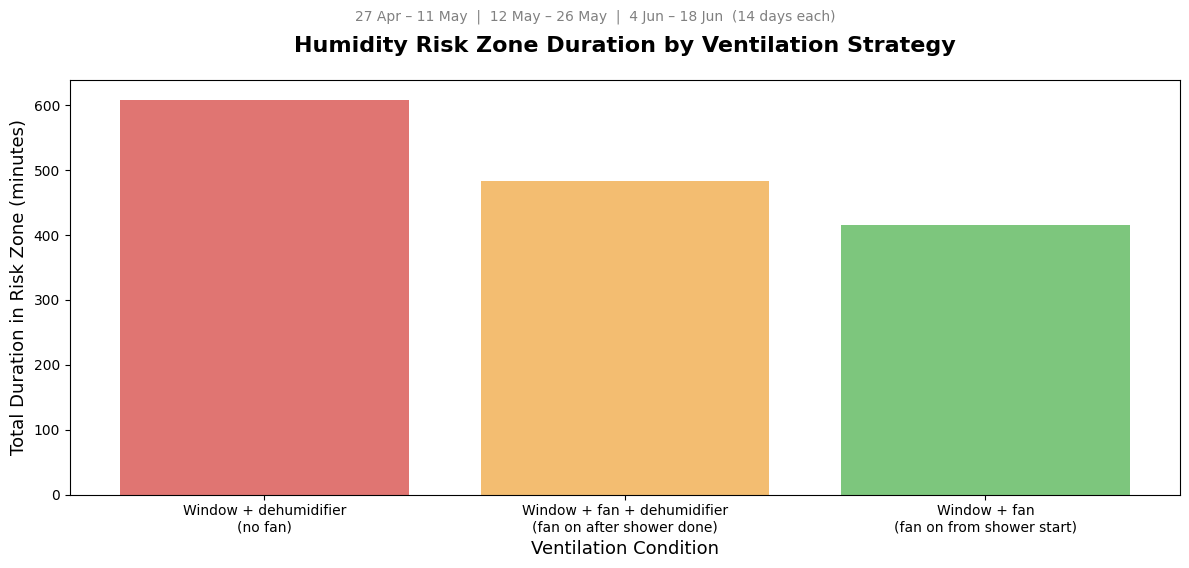

In [610]:

_df1['in_event'] = _df1['spread'] <= 3
_df1['event_start'] = (_df1['in_event']) & ((~_df1['in_event'].shift(1).fillna(False)).astype(bool))

#order changed
_df1['event_id'] = _df1['event_start'].cumsum()
filtered = _df1[_df1['in_event'] == True].copy()

ep =filtered.groupby('event_id')
ep = ep['ts'].agg(start_time='min', end_time='max')
ep['duration'] = (((ep['end_time'] - ep['start_time']).dt.total_seconds())/60.0).round(1)
THRESHOLD = 1
ep = ep[ep['duration']>THRESHOLD]
total_duration = ep['duration'].sum().round(1)


_df2['in_event'] = _df2['spread'] <= 3
_df2['event_start'] = (_df2['in_event']) & ((~_df2['in_event'].shift(1).fillna(False)).astype(bool))
#order changed
_df2['event_id'] = _df2['event_start'].cumsum()
filtered2 = _df2[_df2['in_event'] == True].copy()

ep2 =filtered2.groupby('event_id')
ep2 = ep2['ts'].agg(start_time='min', end_time='max')
ep2['duration'] = (((ep2['end_time'] - ep2['start_time']).dt.total_seconds())/60.0).round(1)
ep2 = ep2[ep2['duration'] > THRESHOLD]
total_duration2 = ep2['duration'].sum().round(1)


_df3['in_event'] = _df3['spread'] <= 3
_df3['event_start'] = (_df3['in_event']) & ((~_df3['in_event'].shift(1).fillna(False)).astype(bool))
#order changed

_df3['event_id'] = _df3['event_start'].cumsum()
filtered3 = _df3[_df3['in_event'] == True].copy()

ep3 =filtered3.groupby('event_id')
ep3 = ep3['ts'].agg(start_time='min', end_time='max')
ep3['duration'] = (((ep3['end_time'] - ep3['start_time']).dt.total_seconds())/60.0).round(1)
ep3 = ep3[ep3['duration'] > THRESHOLD]
total_duration3 = ep3['duration'].sum().round(1)

print("total_sum1: ", total_duration)
print("total_sum2: ", total_duration2)
print("total_sum3: ", total_duration3)


x = [
    "Window + dehumidifier\n(no fan)",
    "Window + fan + dehumidifier\n(fan on after shower done)",
    "Window + fan\n(fan on from shower start)",
]
y = [total_duration, total_duration2, total_duration3]
fig,ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x,
    y,
    color=['#d9534f', '#f0ad4e', '#5cb85c'],
    alpha=0.8
)


ax.set_title('Humidity Risk Zone Duration by Ventilation Strategy', fontsize=16, fontweight='bold', pad=20)
fig.text(0.5, 0.92, '27 Apr – 11 May  |  12 May – 26 May  |  4 Jun – 18 Jun  (14 days each)', 
         ha='center', fontsize=10, color='gray')

plt.xlabel('Ventilation Condition', fontsize=13)
plt.ylabel('Total Duration in Risk Zone (minutes)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# 샤워횟수비교

# 박스수염



Total risk events in Window 1:  47
Total risk events in Window 2:  48
Total risk events in Window 3:  43


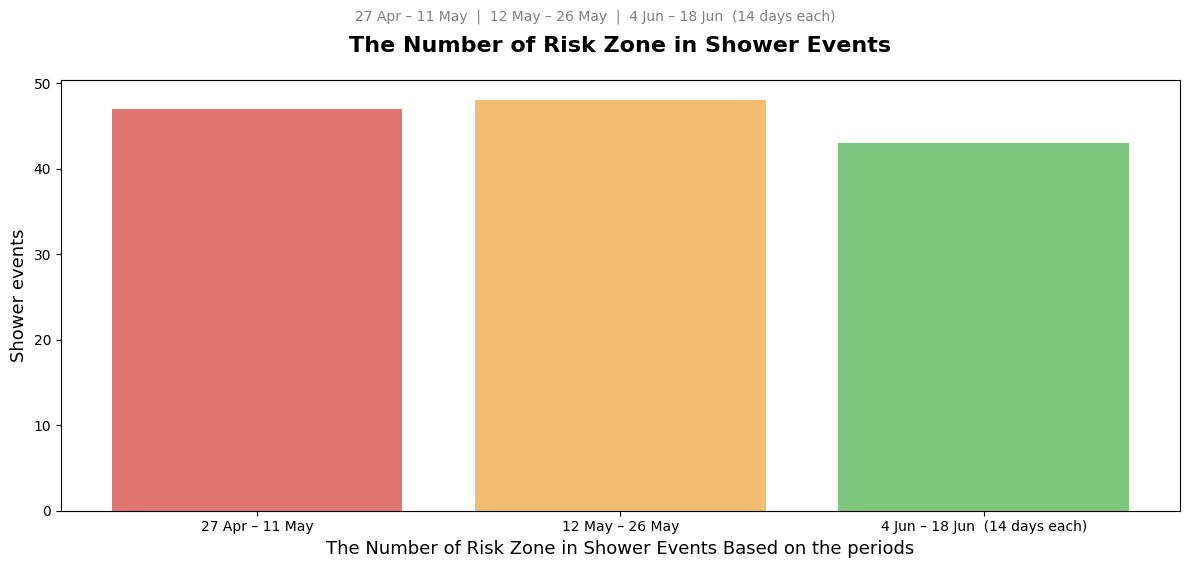

In [611]:
count_events1 = len(ep)
count_events2 = len(ep2)
count_events3 = len(ep3)

print("Total risk events in Window 1: ", count_events1)
print("Total risk events in Window 2: ", count_events2)
print("Total risk events in Window 3: ", count_events3)

x = [
    "27 Apr – 11 May",
    "12 May – 26 May",
    "4 Jun – 18 Jun  (14 days each)",
]
y = [count_events1, count_events2, count_events3]
fig,ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x,
    y,
    color=['#d9534f', '#f0ad4e', '#5cb85c'],
    alpha=0.8
)


ax.set_title('The Number of Risk Zone in Shower Events', fontsize=16, fontweight='bold', pad=20)
fig.text(0.5, 0.92, '27 Apr – 11 May  |  12 May – 26 May  |  4 Jun – 18 Jun  (14 days each)', 
         ha='center', fontsize=10, color='gray')

plt.xlabel('The Number of Risk Zone in Shower Events Based on the periods', fontsize=13)
plt.ylabel('Shower events', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
